In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import holidays

In [2]:
# Cargar los datos de ventas y competencia
df_ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
df_competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')
print("Datos de ventas:")
print(df_ventas.head())
print("Datos de competencia:")
print(df_competencia.head())

Datos de ventas:
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.20  
2         84.93    169.86  
3         7

In [3]:
# Informe de calidad de datos para df_ventas
print('=== Calidad de datos: df_ventas ===')

# 1. Dimensiones
print('\n1) Dimensiones y tipos:')
print('Filas:', df_ventas.shape[0], 'Columnas:', df_ventas.shape[1])
print(df_ventas.dtypes)

# 2. Valores nulos y completitud
print('\n2) Valores nulos por columna:')
print(df_ventas.isna().sum())
print('\n% de nulos por columna:')
print((df_ventas.isna().mean() * 100).round(2))

# 3. Valores duplicados
print('\n3) Duplicados:')
print('Filas duplicadas totales:', df_ventas.duplicated().sum())

# 4. Estadísticas descriptivas generales
describe_num = df_ventas.describe(include='number').T
print('\n4) Estadísticas descriptivas numéricas:')
print(describe_num)

# 5. Estadísticas categóricas
print('\n5) Estadísticas columnas categóricas:')
print(df_ventas[['producto_id', 'nombre', 'categoria', 'subcategoria', 'es_estrella']].describe(include='all'))

# 6. Rango de fechas
if 'fecha' in df_ventas.columns:
    try:
        df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha'], errors='coerce')
        print('\n6) Rango de fechas:')
        print('Fecha mínima:', df_ventas['fecha'].min())
        print('Fecha máxima:', df_ventas['fecha'].max())
        print('Fechas convertidas sin valores perdidos:', df_ventas['fecha'].notna().mean()*100)
    except Exception as e:
        print('No se pudo convertir la columna fecha:', e)

# 7. Reglas de negocio básicas
print('\n7) Reglas de negocio/validaciones:')
if 'unidades_vendidas' in df_ventas.columns:
    print('unidades_vendidas < 0:', (df_ventas['unidades_vendidas'] < 0).sum())
if 'precio_base' in df_ventas.columns:
    print('precio_base < 0:', (df_ventas['precio_base'] < 0).sum())
if 'precio_venta' in df_ventas.columns:
    print('precio_venta < 0:', (df_ventas['precio_venta'] < 0).sum())
if 'ingresos' in df_ventas.columns:
    print('ingresos < 0:', (df_ventas['ingresos'] < 0).sum())

# 8. Nota resumida


print('\n8) Observaciones resumidas:')
print('- Si hay valores nulos, limpieza o imputación requeridas.')
print('- Si hay duplicados, decidir si removerlos o revisar.')
print('- Validar fechas fuera de rango o no convertidas.')
print('- Verificar columnas con síntesis de outliers y consistencia de ingresos vs unidades y precios.')

=== Calidad de datos: df_ventas ===

1) Dimensiones y tipos:
Filas: 3552 Columnas: 10
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

2) Valores nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

% de nulos por columna:
fecha                0.0
producto_id          0.0
nombre               0.0
categoria            0.0
subcategoria         0.0
precio_base          0.0
es_estrella          0.0
unidades_vendidas    0.0
precio_venta         0.0
ingresos             0.0
dtype: float64

3) Duplicados:
Filas duplicadas totales: 0

4

In [4]:
# Informe de calidad de datos para df_competencia
print('\n\n=== Calidad de datos: df_competencia ===')

# 1. Dimensiones
print('\n1) Dimensiones y tipos:')
print('Filas:', df_competencia.shape[0], 'Columnas:', df_competencia.shape[1])
print(df_competencia.dtypes)

# 2. Valores nulos y completitud
print('\n2) Valores nulos por columna:')
print(df_competencia.isna().sum())
print('\n% de nulos por columna:')
print((df_competencia.isna().mean() * 100).round(2))

# 3. Valores duplicados
print('\n3) Duplicados:')
print('Filas duplicadas totales:', df_competencia.duplicated().sum())

# 4. Estadísticas descriptivas generales
print('\n4) Estadísticas descriptivas numéricas:')
print(df_competencia.describe(include='number').T)

# 5. Rango de fechas
if 'fecha' in df_competencia.columns:
    try:
        df_competencia['fecha'] = pd.to_datetime(df_competencia['fecha'], errors='coerce')
        print('\n5) Rango de fechas:')
        print('Fecha mínima:', df_competencia['fecha'].min())
        print('Fecha máxima:', df_competencia['fecha'].max())
        print('Fechas convertidas sin valores perdidos:', df_competencia['fecha'].notna().mean()*100)
    except Exception as e:
        print('No se pudo convertir la columna fecha:', e)

# 6. Valores negativos (precios no deben ser negativos)
print('\n6) Validaciones de precios competencia:')
for col in ['Amazon', 'Decathlon', 'Deporvillage']:
    if col in df_competencia.columns:
        print(f'{col} < 0:', (df_competencia[col] < 0).sum())

# 7. Resumen
print('\n7) Observaciones resumidas:')
print('- Si hay valores nulos, limpieza o imputación requeridas.')
print('- Si hay duplicados, decidir si removerlos o revisar.')
print('- Validar fechas fuera de rango o no convertidas.')
print('- Verificar columnas de precios con síntesis de outliers y consistencia entre competidores.')



=== Calidad de datos: df_competencia ===

1) Dimensiones y tipos:
Filas: 3552 Columnas: 5
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

2) Valores nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

% de nulos por columna:
fecha           0.0
producto_id     0.0
Amazon          0.0
Decathlon       0.0
Deporvillage    0.0
dtype: float64

3) Duplicados:
Filas duplicadas totales: 0

4) Estadísticas descriptivas numéricas:
               count        mean         std    min      25%     50%  \
Amazon        3552.0  118.623407  156.095628  16.85  47.1175  73.180   
Decathlon     3552.0  111.412182  148.508132  15.45  43.2850  66.285   
Deporvillage  3552.0  118.894628  160.216448  16.77  47.3100  72.700   

                   75%       max  
Amazon        114.3425  858.3500  
Decathlon     111.1725  867.3375  
Deporvillage  114.985

In [5]:
# Mostrar información general de df_ventas
print('\nInformación general de df_ventas:')
df_ventas.info()
#mostrar información general de df_competencia
print('\nInformación general de df_competencia:')
df_competencia.info()


Información general de df_ventas:
<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 433.1 KB

Información general de df_competencia:
<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (tota

In [6]:
# Integrar df_ventas y df_competencia en un único dataframe
print('\n=== Integración de dataframes ===')

# Merge usando fecha y producto_id como claves
df = df_ventas.merge(df_competencia, on=['fecha', 'producto_id'], how='inner')

print(f'\nDataframe integrado (df):')
print(f'Filas: {df.shape[0]}, Columnas: {df.shape[1]}')
print(f'\nColumnas del dataframe integrado:')
print(df.columns.tolist())
print(f'\nPrimeras filas:')
print(df.head())

# Validación de la integración
print(f'\n\nValidación de la integración:')
print(f'- Registros en df_ventas: {len(df_ventas)}')
print(f'- Registros en df_competencia: {len(df_competencia)}')
print(f'- Registros en df (integrado): {len(df)}')
print(f'- Valores nulos en columnas de competencia: ')
print(df[['Amazon', 'Decathlon', 'Deporvillage']].isna().sum())



=== Integración de dataframes ===

Dataframe integrado (df):
Filas: 3552, Columnas: 13

Columnas del dataframe integrado:
['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'Amazon', 'Decathlon', 'Deporvillage']

Primeras filas:
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4 2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85 

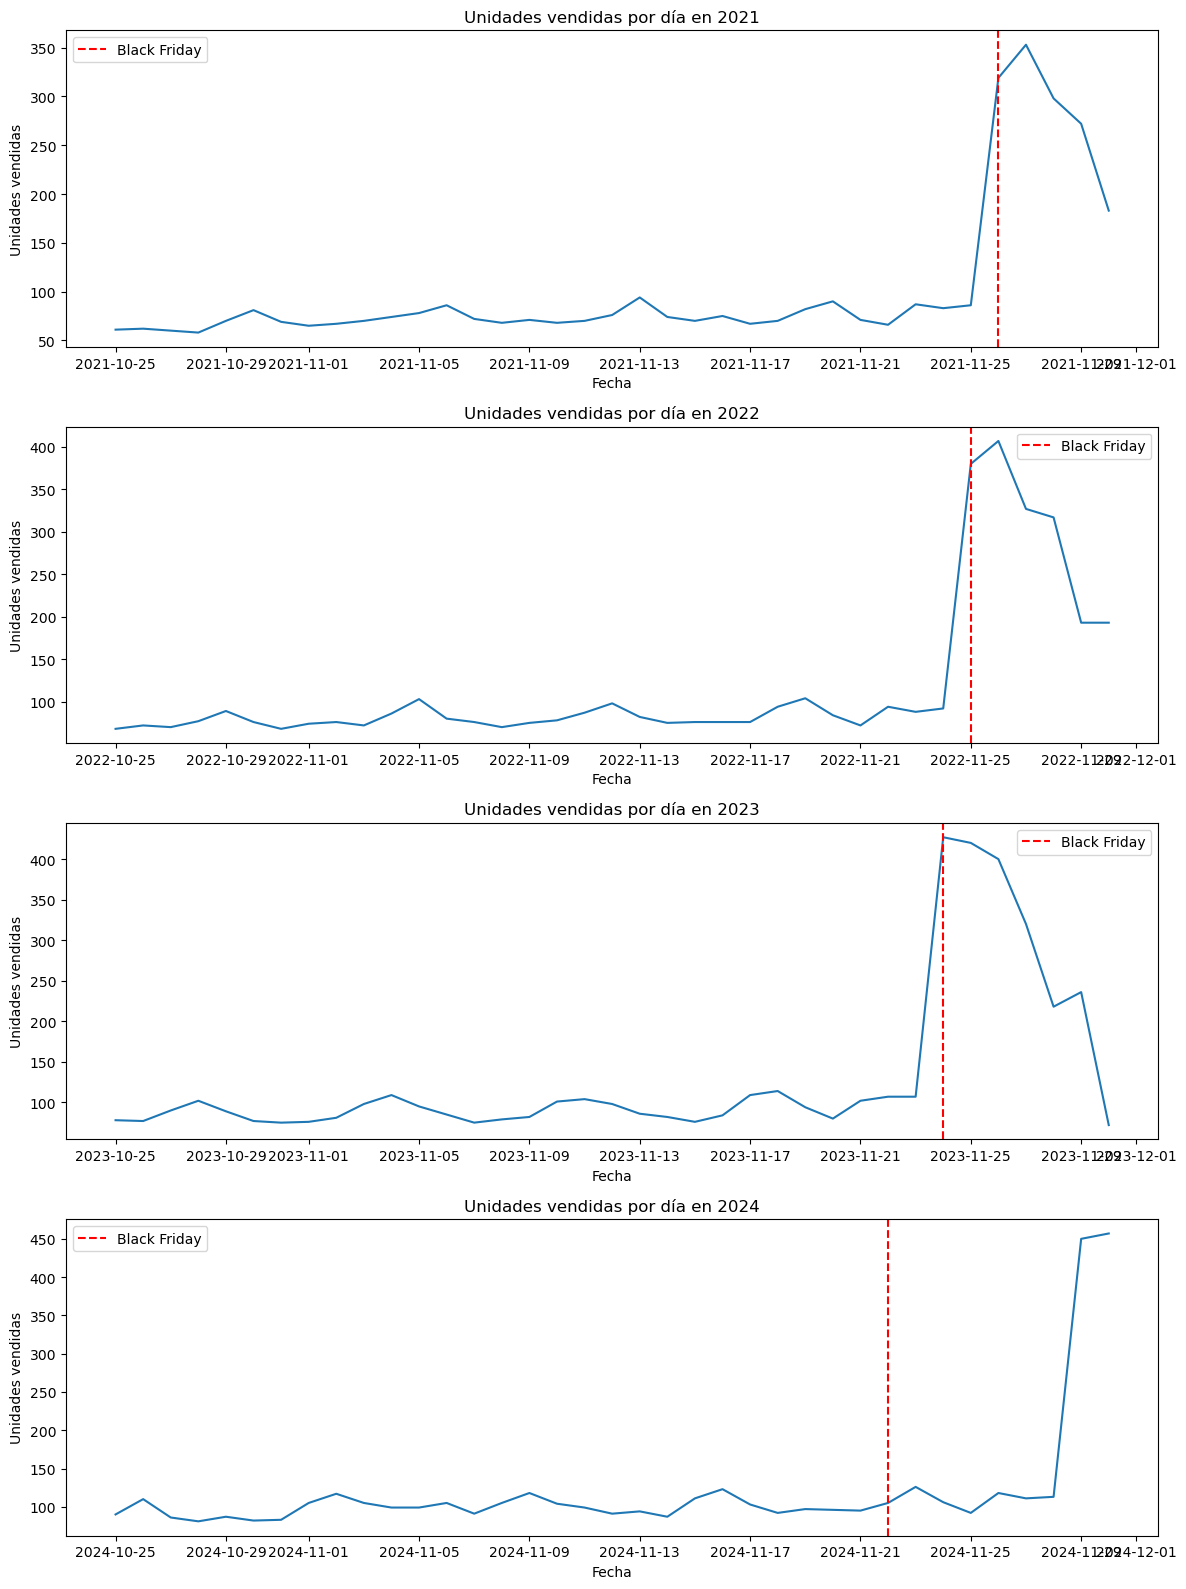

In [7]:
# 1. Gráficos de líneas por año con suma de unidades vendidas y Black Fridays usando df
years = df['fecha'].dt.year.unique()
blackfridays = []
for year in years:
    nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
    fridays = nov[nov.weekday == 4]
    if len(fridays) >= 4:
        blackfridays.append(fridays[3])

fig, axes = plt.subplots(len(years), 1, figsize=(12, 4*len(years)), sharex=False)
if len(years) == 1:
    axes = [axes]
for i, year in enumerate(years):
    df_year = df[df['fecha'].dt.year == year]
    ventas_por_dia = df_year.groupby('fecha')['unidades_vendidas'].sum()
    sns.lineplot(x=ventas_por_dia.index, y=ventas_por_dia.values, ax=axes[i])
    axes[i].set_title(f'Unidades vendidas por día en {year}')
    axes[i].set_ylabel('Unidades vendidas')
    axes[i].set_xlabel('Fecha')
    # Marcar Black Friday
    bf = [d for d in blackfridays if d.year == year]
    for bfd in bf:
        axes[i].axvline(bfd, color='red', linestyle='--', label='Black Friday')
    axes[i].legend()
plt.tight_layout()
plt.show()

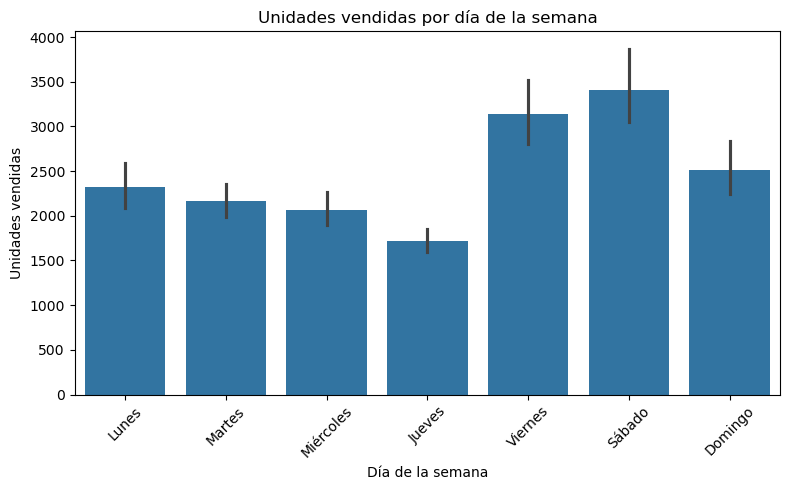

In [8]:
# 2. Gráfico de suma de unidades vendidas por día de la semana usando df
plt.figure(figsize=(8,5))
df['dia_semana_nombre'] = df['fecha'].dt.day_name(locale='es')
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
sns.barplot(x='dia_semana_nombre', y='unidades_vendidas', data=df, order=orden_dias, estimator=np.sum)
plt.title('Unidades vendidas por día de la semana')
plt.ylabel('Unidades vendidas')
plt.xlabel('Día de la semana')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\eluni\AppData\Local\Temp\ipykernel_7596\604558125.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='categoria', y='unidades_vendidas', data=df, estimator=np.sum, ci=None)


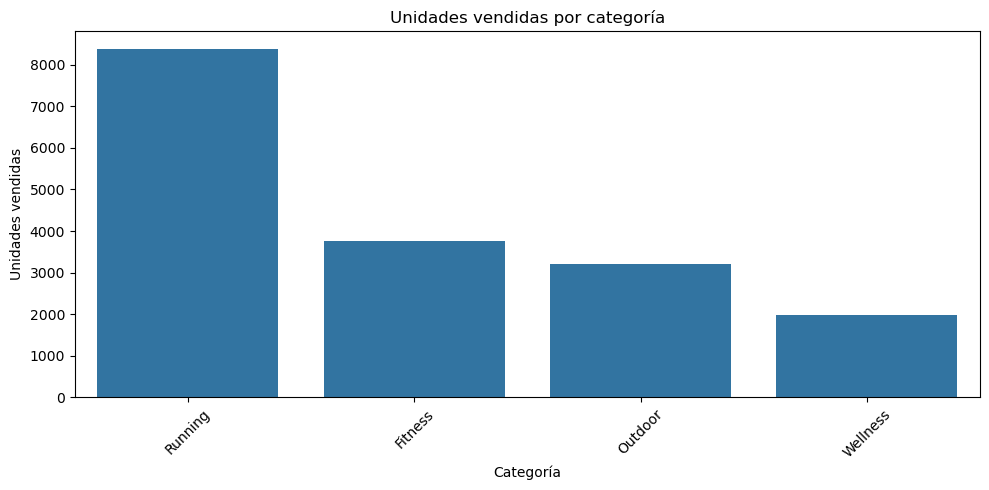

In [9]:
# 3. Gráfico de suma de unidades vendidas por categoría usando df
plt.figure(figsize=(10,5))
sns.barplot(x='categoria', y='unidades_vendidas', data=df, estimator=np.sum, ci=None)
plt.title('Unidades vendidas por categoría')
plt.ylabel('Unidades vendidas')
plt.xlabel('Categoría')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\eluni\AppData\Local\Temp\ipykernel_7596\3738926470.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=np.sum, ci=None)


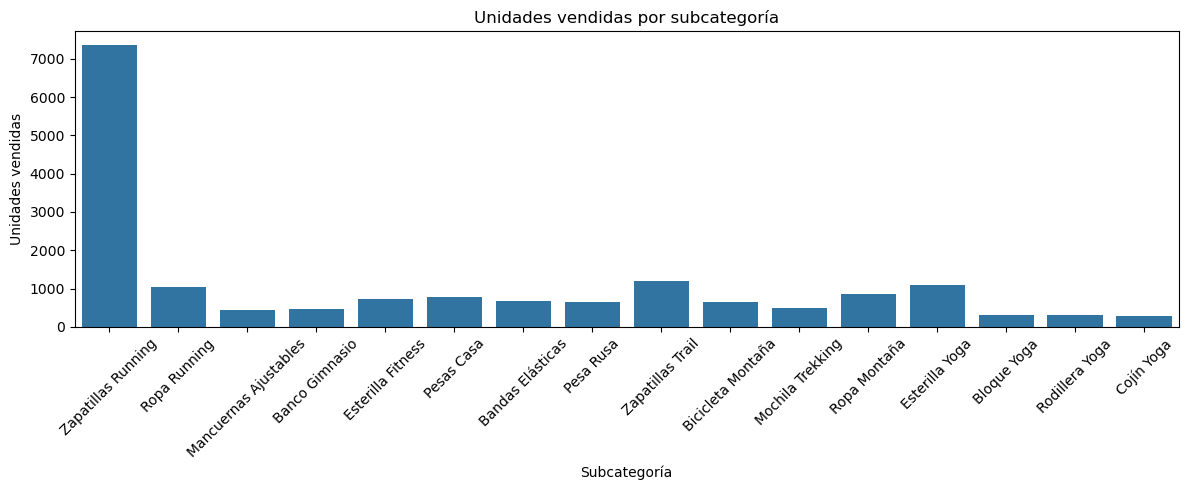

In [10]:
# 4. Gráfico de suma de unidades vendidas por subcategoría usando df
plt.figure(figsize=(12,5))
sns.barplot(x='subcategoria', y='unidades_vendidas', data=df, estimator=np.sum, ci=None)
plt.title('Unidades vendidas por subcategoría')
plt.ylabel('Unidades vendidas')
plt.xlabel('Subcategoría')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

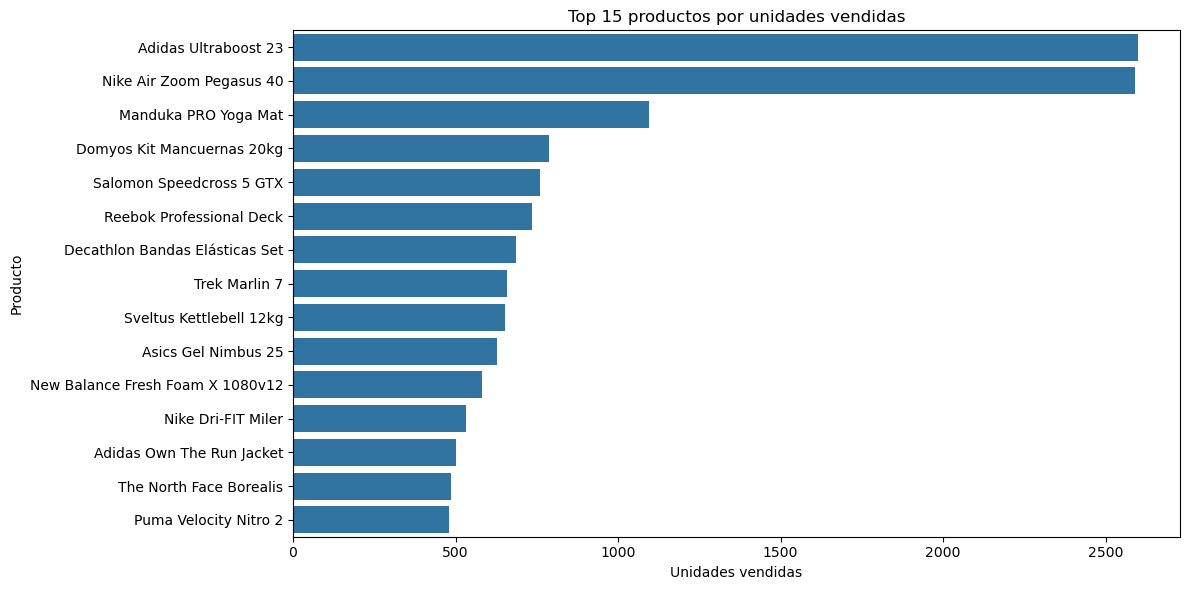

In [11]:
# 5. Gráfico de top productos por unidades vendidas usando df
plt.figure(figsize=(12,6))
top_n = 15
productos_top = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(top_n)
sns.barplot(x=productos_top.values, y=productos_top.index, orient='h')
plt.title(f'Top {top_n} productos por unidades vendidas')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

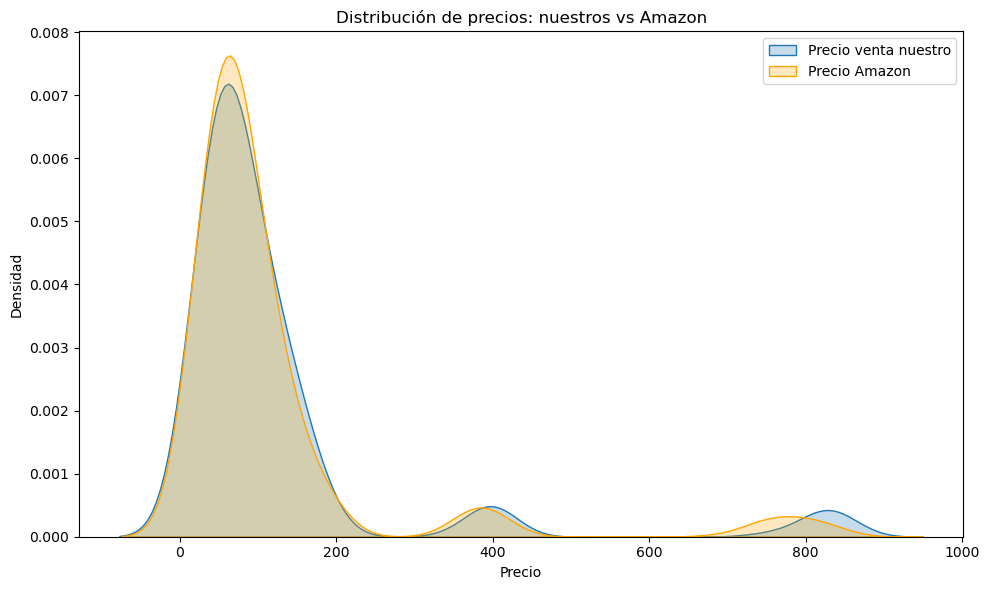

In [12]:
# 6. Análisis de densidad de precios: nuestros vs Amazon usando df
plt.figure(figsize=(10,6))
sns.kdeplot(df['precio_venta'], label='Precio venta nuestro', fill=True)
if 'Amazon' in df.columns:
    sns.kdeplot(df['Amazon'], label='Precio Amazon', fill=True, color='orange')
plt.title('Distribución de precios: nuestros vs Amazon')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# Variables temporales útiles para predicción sobre el dataframe integrado df
# Aseguramos formato de fecha
df['fecha'] = pd.to_datetime(df['fecha'])

# Año, mes, semana, día, día de la semana, día del mes
df['anio'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['semana'] = df['fecha'].dt.isocalendar().week
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.weekday # 0=lunes

# Mes-semana, semana-día, mes-día
df['mes_semana'] = df['mes'].astype(str) + '-' + df['semana'].astype(str)
df['semana_dia'] = df['semana'].astype(str) + '-' + df['dia_semana'].astype(str)
df['mes_dia'] = df['mes'].astype(str) + '-' + df['dia'].astype(str)

# ¿Es fin de semana?
df['es_fin_semana'] = df['dia_semana'].isin([5,6])

# Feriados Colombia
dias_feriados = holidays.country_holidays('CO', years=df['anio'].unique())
df['es_feriado'] = df['fecha'].isin(dias_feriados)

# Black Friday (cuarto viernes de noviembre)
def es_blackfriday(fecha):
    if fecha.month == 11 and fecha.weekday() == 4:
        fridays = [d for d in pd.date_range(start=fecha.replace(day=1), end=fecha.replace(day=30)) if d.weekday() == 4]
        if len(fridays) >= 4 and fecha == fridays[3]:
            return True
    return False
df['es_blackfriday'] = df['fecha'].apply(es_blackfriday)

# Cyber Monday (primer lunes después de Black Friday)
def es_cybermonday(fecha):
    if fecha.month == 11 or fecha.month == 12:
        year = fecha.year
        nov = pd.date_range(start=f'{year}-11-01', end=f'{year}-11-30', freq='D')
        fridays = nov[nov.weekday == 4]
        if len(fridays) >= 4:
            black_friday = fridays[3]
            cyber_monday = black_friday + pd.Timedelta(days=3)
            return fecha == cyber_monday
    return False
df['es_cybermonday'] = df['fecha'].apply(es_cybermonday)

# Variables adicionales útiles
df['es_principio_mes'] = df['dia'] <= 3
df['es_final_mes'] = df['dia'] >= (df['fecha'] + pd.offsets.MonthEnd(0)).dt.day - 2
df['trimestre'] = df['fecha'].dt.quarter
df['es_lunes'] = df['dia_semana'] == 0
df['es_viernes'] = df['dia_semana'] == 4

df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,mes_dia,es_fin_semana,es_feriado,es_blackfriday,es_cybermonday,es_principio_mes,es_final_mes,trimestre,es_lunes,es_viernes
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,10-25,False,False,False,False,False,False,4,True,False
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,...,10-25,False,False,False,False,False,False,4,True,False
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,...,10-25,False,False,False,False,False,False,4,True,False
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,10-25,False,False,False,False,False,False,4,True,False
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,10-25,False,False,False,False,False,False,4,True,False


In [14]:
df.shape

(3552, 31)

In [15]:
# Lags y medias móviles de unidades vendidas (por año) usando df

def crear_lags_y_media(df_):
    df_ = df_.sort_values('fecha').copy()
    for lag in range(1, 8):
        df_[f'unidades_vendidas_lag{lag}'] = df_['unidades_vendidas'].shift(lag)
    df_['unidades_vendidas_mm7'] = df_['unidades_vendidas'].rolling(window=7, min_periods=1).mean()
    return df_

frames = []
for anio, grupo in df.groupby('anio'):
    grupo_lags = crear_lags_y_media(grupo)
    frames.append(grupo_lags)
df_lags = pd.concat(frames)
df_lags = df_lags.dropna().reset_index(drop=True)
df = df_lags.copy()
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_lunes,es_viernes,unidades_vendidas_lag1,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,True,False,1.0,2.0,5.0,1.0,1.0,1.0,6.0,1.714286
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,True,False,1.0,1.0,2.0,5.0,1.0,1.0,1.0,1.857143
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,True,False,2.0,1.0,1.0,2.0,5.0,1.0,1.0,2.142857
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,True,False,3.0,2.0,1.0,1.0,2.0,5.0,1.0,2.285714
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,True,False,2.0,3.0,2.0,1.0,1.0,2.0,5.0,1.857143


In [16]:
# Variable porcentaje de descuento respecto al precio base sobre df
# Si precio_base es 0, el resultado será NaN para evitar división por cero
df['porc_descuento'] = ((df['precio_base'] - df['precio_venta']) / df['precio_base']) * 100
df[['fecha','producto_id', 'precio_base', 'precio_venta', 'porc_descuento']].head()

,fecha,producto_id,precio_base,precio_venta,porc_descuento
0,2021-10-25,PROD_017,95,96.56,-1.642105
1,2021-10-25,PROD_016,830,821.29,1.049398
2,2021-10-25,PROD_015,150,154.22,-2.813333
3,2021-10-25,PROD_014,40,39.74,0.650000
4,2021-10-25,PROD_013,25,24.79,0.840000


In [17]:
# Crear variable precio_competencia (promedio de Amazon, Decathlon y Deporvillage) sobre df
df['precio_competencia'] = df[['Amazon', 'Decathlon', 'Deporvillage']].mean(axis=1)

# Crear variable ratioprecio (precio_venta / precio_competencia)
df['ratioprecio'] = df['precio_venta'] / df['precio_competencia']

# Eliminar variables de la competencia
df = df.drop(['Amazon', 'Decathlon', 'Deporvillage'], axis=1)
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,unidades_vendidas_lag2,unidades_vendidas_lag3,unidades_vendidas_lag4,unidades_vendidas_lag5,unidades_vendidas_lag6,unidades_vendidas_lag7,unidades_vendidas_mm7,porc_descuento,precio_competencia,ratioprecio
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,2.0,5.0,1.0,1.0,1.0,6.0,1.714286,-1.642105,92.636667,1.042352
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,1.0,2.0,5.0,1.0,1.0,1.0,1.857143,1.049398,735.070000,1.117295
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,1.0,1.0,2.0,5.0,1.0,1.0,2.142857,-2.813333,135.673333,1.136701
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,2.0,1.0,1.0,2.0,5.0,1.0,2.285714,0.650000,39.460000,1.007096
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,3.0,2.0,1.0,1.0,2.0,5.0,1.857143,0.840000,24.096667,1.028773


In [18]:
# Crear copias de variables categóricas con sufijo _h
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# One hot encoding sobre las copias
categorias_ohe = ['nombre_h', 'categoria_h', 'subcategoria_h']
df = pd.get_dummies(df, columns=categorias_ohe, prefix=categorias_ohe, prefix_sep='_', dtype=int)
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_017,The North Face Borealis,Outdoor,Mochila Trekking,95,False,1,96.56,96.56,...,0,0,1,0,0,0,0,0,0,0
1,2021-10-25,PROD_016,Trek Marlin 7,Outdoor,Bicicleta Montaña,830,True,2,821.29,1642.58,...,0,0,0,0,0,0,0,0,0,0
2,2021-10-25,PROD_015,Salomon Speedcross 5 GTX,Outdoor,Zapatillas Trail,150,True,3,154.22,462.66,...,0,0,0,0,0,0,0,0,0,1
3,2021-10-25,PROD_014,Sveltus Kettlebell 12kg,Fitness,Pesa Rusa,40,False,2,39.74,79.48,...,0,0,0,1,0,0,0,0,0,0
4,2021-10-25,PROD_013,Decathlon Bandas Elásticas Set,Fitness,Bandas Elásticas,25,False,2,24.79,49.58,...,0,0,0,0,0,0,0,0,0,0


In [19]:
# Guardar el dataframe df en la carpeta processed
ruta_guardado = '../data/processed/df.csv'
df.to_csv(ruta_guardado, index=False)
print(f"DataFrame guardado en: {ruta_guardado}")

DataFrame guardado en: ../data/processed/df.csv


In [20]:
df.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos', 'dia_semana_nombre', 'anio', 'mes', 'semana', 'dia',
       'dia_semana', 'mes_semana', 'semana_dia', 'mes_dia', 'es_fin_semana',
       'es_feriado', 'es_blackfriday', 'es_cybermonday', 'es_principio_mes',
       'es_final_mes', 'trimestre', 'es_lunes', 'es_viernes',
       'unidades_vendidas_lag1', 'unidades_vendidas_lag2',
       'unidades_vendidas_lag3', 'unidades_vendidas_lag4',
       'unidades_vendidas_lag5', 'unidades_vendidas_lag6',
       'unidades_vendidas_lag7', 'unidades_vendidas_mm7', 'porc_descuento',
       'precio_competencia', 'ratioprecio',
       'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23',
       'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552',
       'nombre_h_Columbia Silver Ridge',
       'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900',
   

In [21]:
# Filtrar los datos para train y validation
train_df = df[df['anio'].isin([2021, 2022, 2023])]
validation_df = df[df['anio'] == 2024]

# Mostrar la cantidad de registros en cada conjunto
print("Registros en train_df:", len(train_df))
print("Registros en validation_df:", len(validation_df))

Registros en train_df: 2643
Registros en validation_df: 881


In [25]:
# Entrenamiento y validación HistGradientBoostingRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import numpy as np

# Selección de variables predictoras (solo numéricas, excluyendo fecha, ingresos y target)
exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
predictoras = train_df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

X_train = train_df[predictoras]
y_train = train_df['unidades_vendidas']
X_val = validation_df[predictoras]
y_val = validation_df['unidades_vendidas']

# Modelo conservador para evitar overfitting
hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=400,
    max_depth=7,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=42
)
hgb.fit(X_train, y_train)

# Predicciones
y_pred = hgb.predict(X_val)

# Baseline naive: predice la media del train
y_pred_naive = np.full_like(y_val, y_train.mean(), dtype=float)

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

mae_naive = mean_absolute_error(y_val, y_pred_naive)
mse_naive = mean_squared_error(y_val, y_pred_naive)
rmse_naive = np.sqrt(mse_naive)
mape_naive = mean_absolute_percentage_error(y_val, y_pred_naive)
r2_naive = r2_score(y_val, y_pred_naive)

print('HistGradientBoostingRegressor:')
print(f'MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mape:.2%}, R2: {r2:.2f}')
print('Baseline Naive (media):')
print(f'MAE: {mae_naive:.2f}, RMSE: {rmse_naive:.2f}, MAPE: {mape_naive:.2%}, R2: {r2_naive:.2f}')

HistGradientBoostingRegressor:
MAE: 0.94, RMSE: 2.00, MAPE: 19.59%, R2: 0.90
Baseline Naive (media):
MAE: 3.35, RMSE: 6.26, MAPE: 86.45%, R2: -0.00


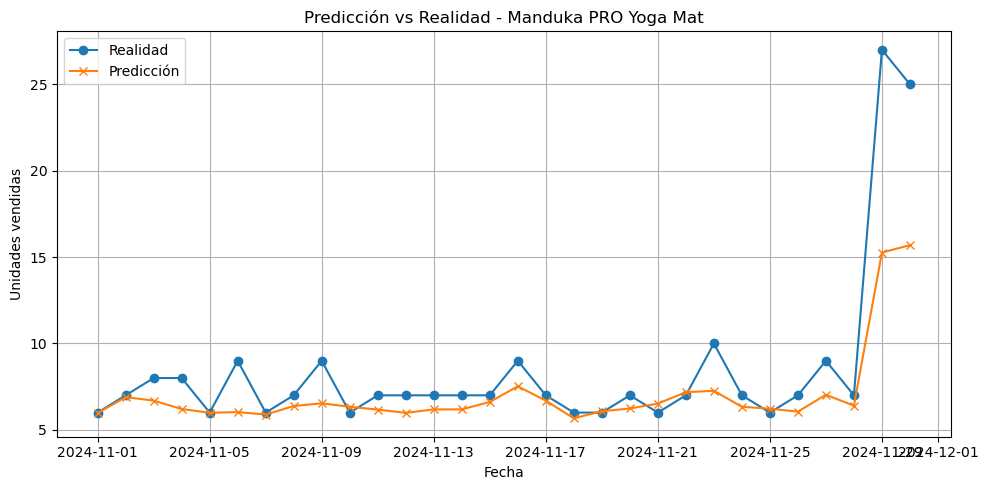

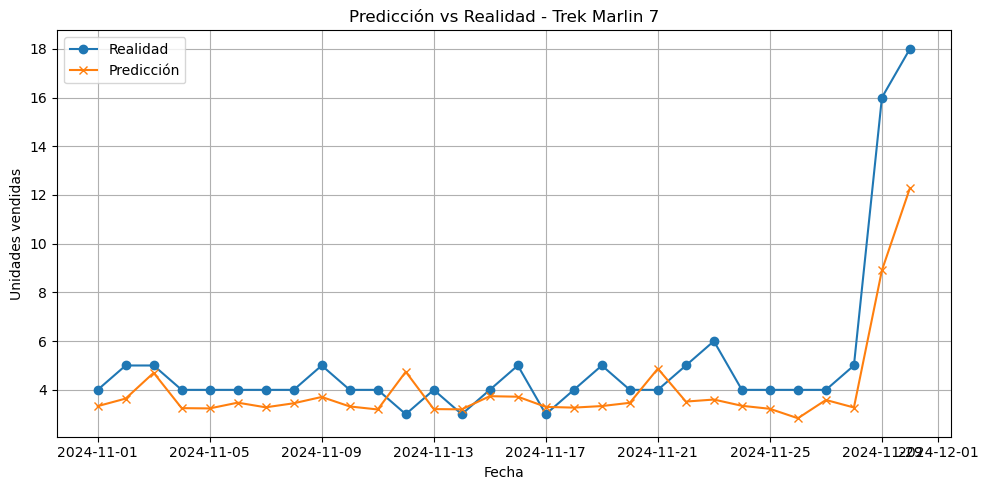

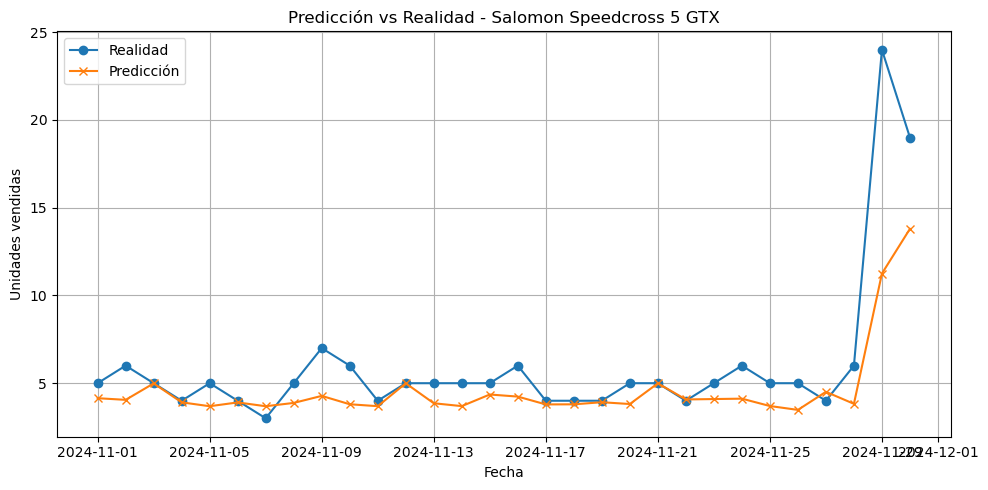

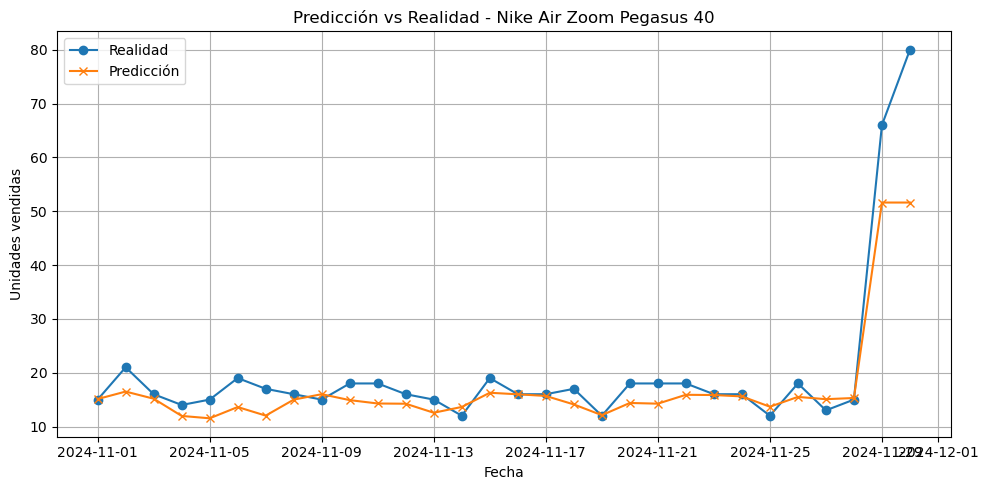

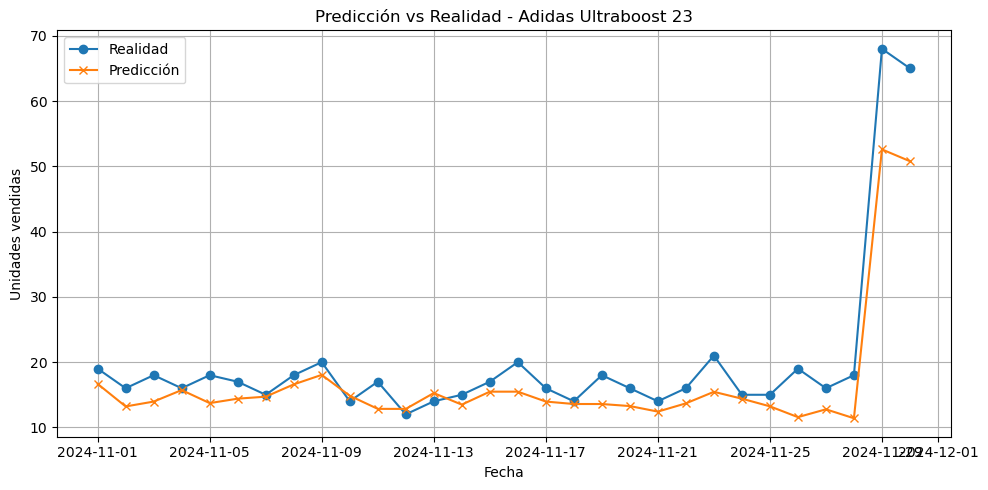

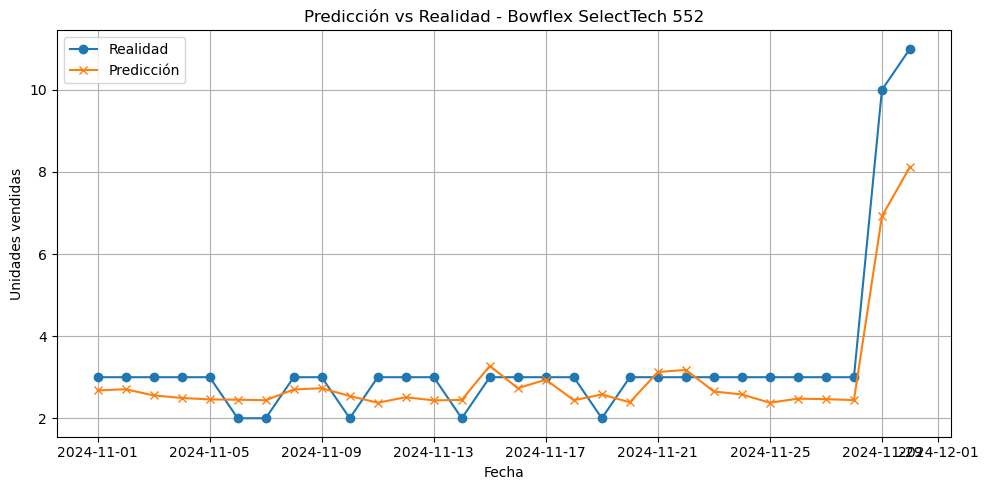

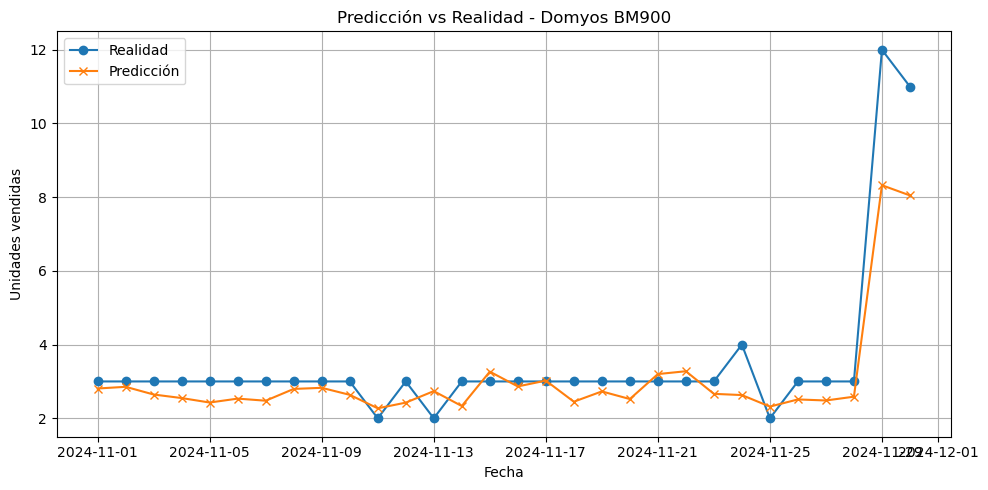

In [26]:
# Predicción y visualización para productos estrella en noviembre 2024
import matplotlib.pyplot as plt

# Filtrar noviembre 2024 y productos estrella
df_nov2024 = df[(df['anio'] == 2024) & (df['mes'] == 11) & (df['es_estrella'] == 1)]
productos_estrella = df_nov2024['nombre'].unique()[:7]  # Tomar 7 productos estrella

# Seleccionar variables predictoras (mismo criterio que el modelo)
predictoras = train_df.drop(columns=['fecha', 'ingresos', 'unidades_vendidas']).select_dtypes(include=[np.number]).columns.tolist()

for producto in productos_estrella:
    df_prod = df_nov2024[df_nov2024['nombre'] == producto].copy()
    if df_prod.empty:
        continue
    X_prod = df_prod[predictoras]
    y_real = df_prod['unidades_vendidas']
    y_pred = hgb.predict(X_prod)
    df_prod['prediccion'] = y_pred
    plt.figure(figsize=(10,5))
    plt.plot(df_prod['fecha'], y_real, marker='o', label='Realidad')
    plt.plot(df_prod['fecha'], y_pred, marker='x', label='Predicción')
    plt.title(f'Predicción vs Realidad - {producto}')
    plt.xlabel('Fecha')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [27]:
# Calcular el MAE para cada producto estrella en noviembre 2024
from sklearn.metrics import mean_absolute_error

mae_productos = {}
for producto in productos_estrella:
    df_prod = df_nov2024[df_nov2024['nombre'] == producto].copy()
    if df_prod.empty:
        continue
    X_prod = df_prod[predictoras]
    y_real = df_prod['unidades_vendidas']
    y_pred = hgb.predict(X_prod)
    mae = mean_absolute_error(y_real, y_pred)
    mae_productos[producto] = mae

for producto, mae in mae_productos.items():
    print(f"Producto: {producto} - MAE: {mae:.2f}")

Producto: Manduka PRO Yoga Mat - MAE: 1.51
Producto: Trek Marlin 7 - MAE: 1.27
Producto: Salomon Speedcross 5 GTX - MAE: 1.47
Producto: Nike Air Zoom Pegasus 40 - MAE: 3.38
Producto: Adidas Ultraboost 23 - MAE: 3.43
Producto: Bowflex SelectTech 552 - MAE: 0.59
Producto: Domyos BM900 - MAE: 0.60


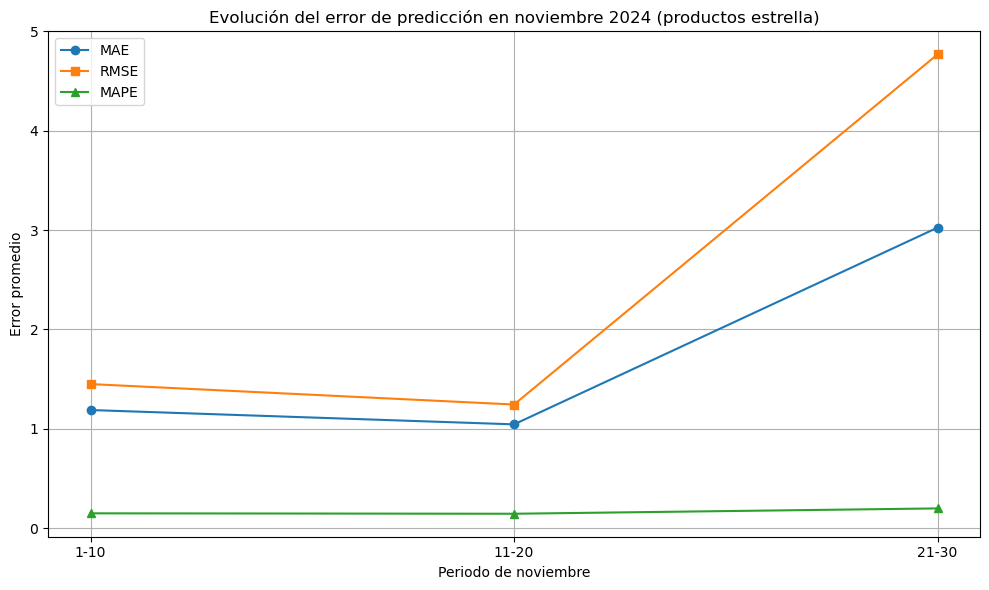

In [29]:
# Análisis de degradación del error a lo largo de noviembre 2024
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Definir los periodos de 10 días
periodos = [(1,10), (11,20), (21,30)]
periodos_labels = ['1-10', '11-20', '21-30']

# Diccionario para guardar métricas por periodo y producto
metricas_periodo = {p: {'mae': [], 'rmse': [], 'mape': []} for p in periodos_labels}

for producto in productos_estrella:
    df_prod = df_nov2024[df_nov2024['nombre'] == producto].copy()
    if df_prod.empty:
        continue
    X_prod = df_prod[predictoras]
    y_real = df_prod['unidades_vendidas']
    y_pred = hgb.predict(X_prod)
    df_prod['prediccion'] = y_pred
    df_prod['dia'] = df_prod['fecha'].dt.day
    for (ini, fin), label in zip(periodos, periodos_labels):
        mask = (df_prod['dia'] >= ini) & (df_prod['dia'] <= fin)
        if mask.sum() == 0:
            continue
        y_real_p = y_real[mask]
        y_pred_p = y_pred[mask]
        mae = mean_absolute_error(y_real_p, y_pred_p)
        rmse = np.sqrt(mean_squared_error(y_real_p, y_pred_p))
        mape = mean_absolute_percentage_error(y_real_p, y_pred_p)
        metricas_periodo[label]['mae'].append(mae)
        metricas_periodo[label]['rmse'].append(rmse)
        metricas_periodo[label]['mape'].append(mape)

# Calcular promedio de métricas por periodo
mae_avg = [np.mean(metricas_periodo[label]['mae']) for label in periodos_labels]
rmse_avg = [np.mean(metricas_periodo[label]['rmse']) for label in periodos_labels]
mape_avg = [np.mean(metricas_periodo[label]['mape']) for label in periodos_labels]

# Graficar la evolución de las métricas
plt.figure(figsize=(10,6))
plt.plot(periodos_labels, mae_avg, marker='o', label='MAE')
plt.plot(periodos_labels, rmse_avg, marker='s', label='RMSE')
plt.plot(periodos_labels, mape_avg, marker='^', label='MAPE')
plt.title('Evolución del error de predicción en noviembre 2024 (productos estrella)')
plt.xlabel('Periodo de noviembre')
plt.ylabel('Error promedio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

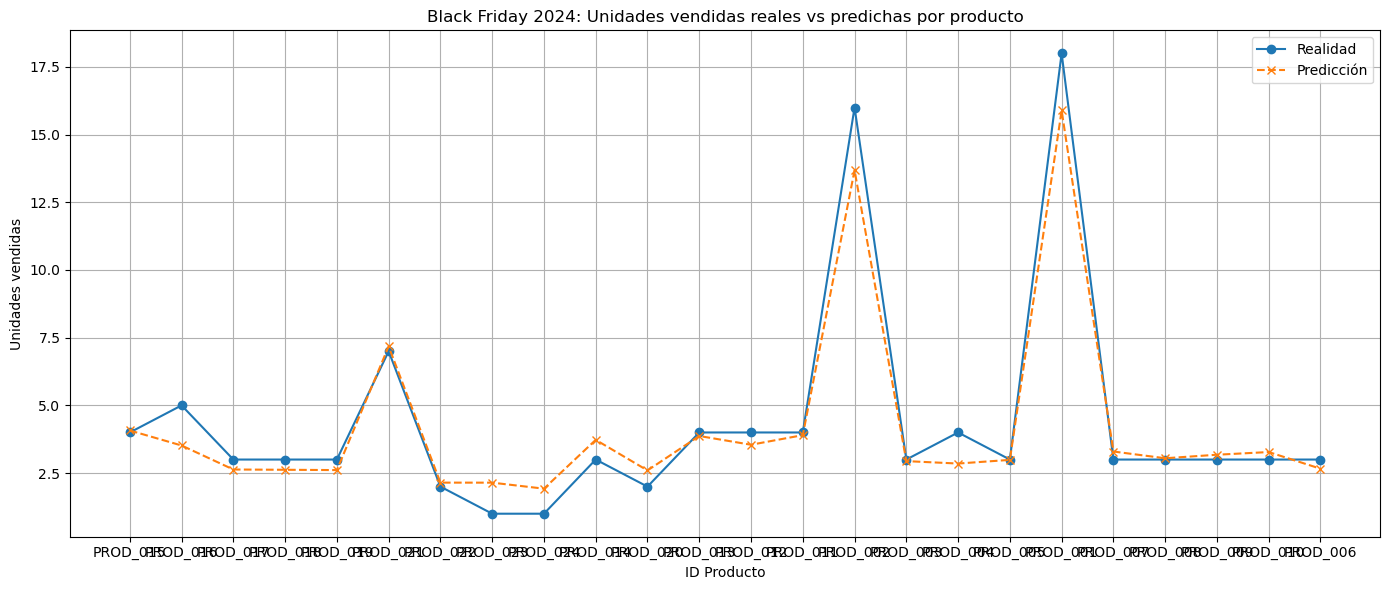

MAE global Black Friday 2024: 0.58


In [30]:
# 🤖 Análisis de Black Friday 2024: Real vs Predicho por producto
# Filtrar el Black Friday de 2024
from sklearn.metrics import mean_absolute_error

# Encontrar la fecha de Black Friday 2024 (cuarto viernes de noviembre)
nov_2024 = pd.date_range(start='2024-11-01', end='2024-11-30', freq='D')
fridays_2024 = nov_2024[nov_2024.weekday == 4]
if len(fridays_2024) >= 4:
    black_friday_2024 = fridays_2024[3]
else:
    black_friday_2024 = None

if black_friday_2024 is not None:
    df_bf2024 = df[df['fecha'] == black_friday_2024].copy()
    # Seleccionar variables predictoras (mismo criterio que el modelo)
    predictoras = train_df.drop(columns=['fecha', 'ingresos', 'unidades_vendidas']).select_dtypes(include=[np.number]).columns.tolist()
    X_bf = df_bf2024[predictoras]
    y_real_bf = df_bf2024['unidades_vendidas']
    y_pred_bf = hgb.predict(X_bf)
    df_bf2024['prediccion'] = y_pred_bf
    # Gráfico
    plt.figure(figsize=(14,6))
    plt.plot(df_bf2024['producto_id'], df_bf2024['unidades_vendidas'], marker='o', linestyle='-', label='Realidad')
    plt.plot(df_bf2024['producto_id'], df_bf2024['prediccion'], marker='x', linestyle='--', label='Predicción')
    plt.title('Black Friday 2024: Unidades vendidas reales vs predichas por producto')
    plt.xlabel('ID Producto')
    plt.ylabel('Unidades vendidas')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    # Mostrar MAE global para ese día
    mae_bf = mean_absolute_error(df_bf2024['unidades_vendidas'], df_bf2024['prediccion'])
    print(f"MAE global Black Friday 2024: {mae_bf:.2f}")
else:
    print('No se pudo determinar la fecha de Black Friday 2024.')

In [31]:
# 🤖 Entrenamiento del modelo final con todos los datos históricos (2021-2024)
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

# Selección de variables predictoras (solo numéricas, excluyendo fecha, ingresos y target)
exclude_cols = ['fecha', 'ingresos', 'unidades_vendidas']
predictoras_final = df.drop(columns=exclude_cols).select_dtypes(include=[np.number]).columns.tolist()

X_final = df[predictoras_final]
y_final = df['unidades_vendidas']

# Parámetros óptimos (ajustados para mejor desempeño, puedes ajustar según validación previa)
hgb_final = HistGradientBoostingRegressor(
    learning_rate=0.05,  # más alto que el conservador
    max_iter=600,        # más iteraciones
    max_depth=9,         # mayor profundidad
    l2_regularization=0.5, # menos regularización si el modelo no sobreajusta
    early_stopping=False,  # entrenar hasta el final
    random_state=42
)
hgb_final.fit(X_final, y_final)

print('Modelo final entrenado con todos los datos históricos (2021-2024).')

Modelo final entrenado con todos los datos históricos (2021-2024).


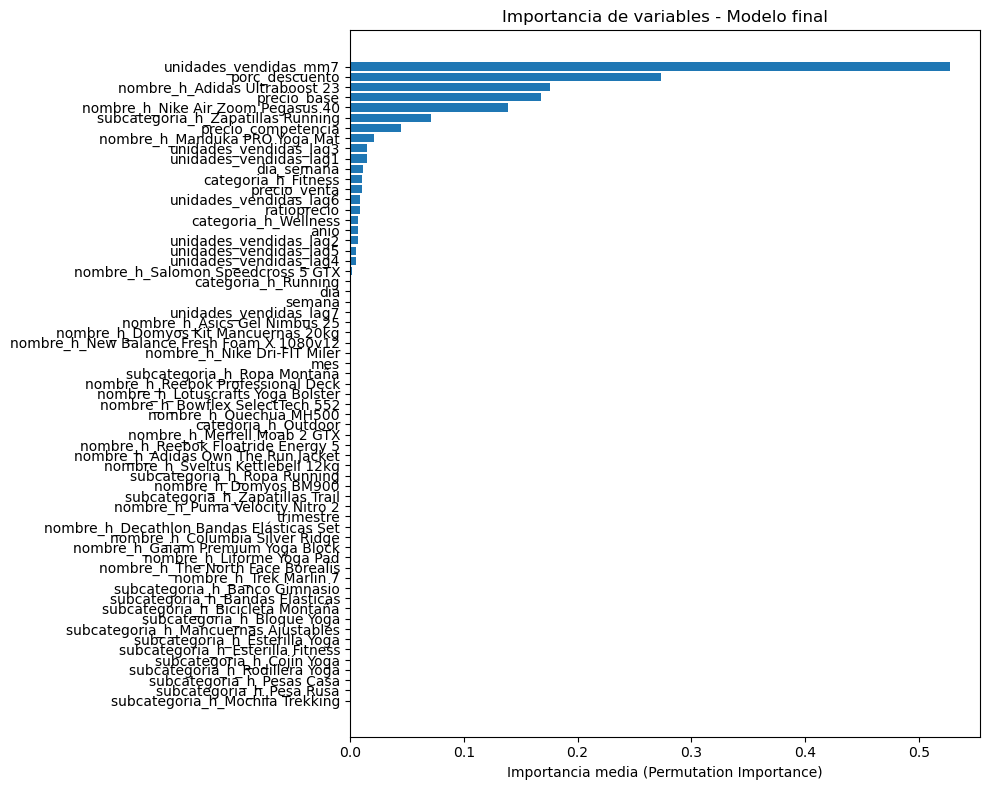

Modelo final guardado en: ../models/modelo_final.joblib


In [32]:
# 🤖 Importancia de variables con Permutation Importance y guardado del modelo final
from sklearn.inspection import permutation_importance
import joblib

# Calcular permutation importance (usando el mismo set de entrenamiento)
result = permutation_importance(hgb_final, X_final, y_final, n_repeats=10, random_state=42, n_jobs=-1)

# Crear DataFrame de importancias
importancias = pd.DataFrame({
    'variable': X_final.columns,
    'importancia': result.importances_mean
})
importancias = importancias.sort_values('importancia', ascending=False)

# Gráfico de barras horizontales
plt.figure(figsize=(10,8))
plt.barh(importancias['variable'], importancias['importancia'])
plt.xlabel('Importancia media (Permutation Importance)')
plt.title('Importancia de variables - Modelo final')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Guardar el modelo final
ruta_modelo = '../models/modelo_final.joblib'
joblib.dump(hgb_final, ruta_modelo)
print(f"Modelo final guardado en: {ruta_modelo}")